<a href="https://colab.research.google.com/github/Nivethanajacob/Calculator/blob/main/Copy_of_Mind_Check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report,
                                     ConfusionMatrixDisplay, confusion_matrix)
import joblib

# **LOad Data**

In [ ]:
df = pd.read_csv('/content/goemotions_full.csv')
df.head()          # shows the first 5 rows so you can see what the data looks like


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  object 
 1   id                    211225 non-null  object 
 2   author                211225 non-null  object 
 3   subreddit             211225 non-null  object 
 4   link_id               211225 non-null  object 
 5   parent_id             211225 non-null  object 
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  

In [ ]:
df.shape

(211225, 37)

## EDA - Vizualization

In [ ]:
FINE_EMOTIONS = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise','neutral'
]

### Emotion Distribution

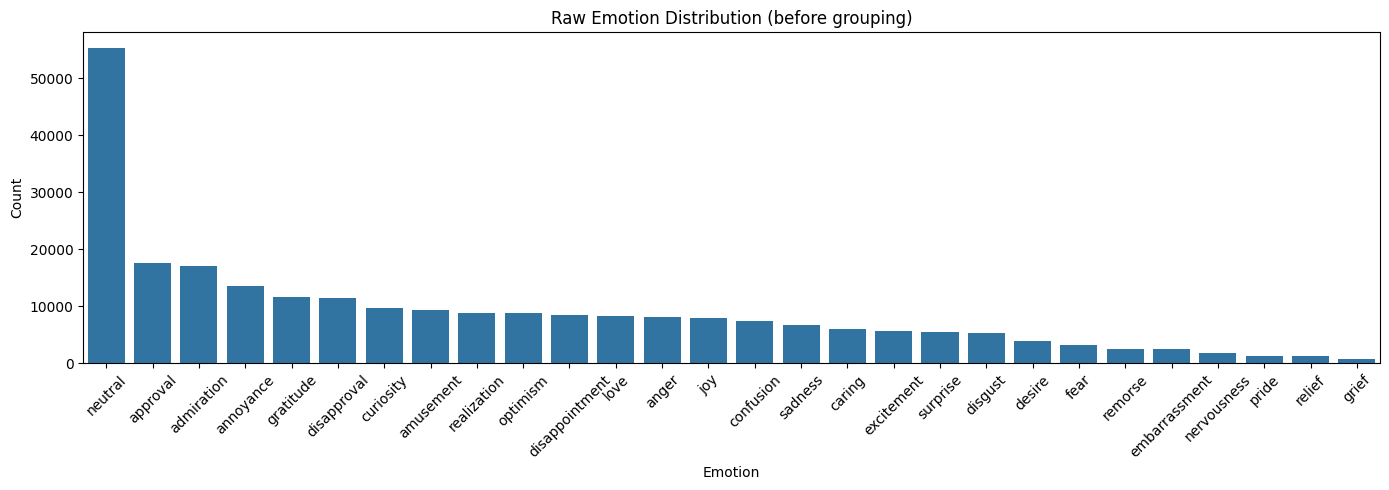

In [ ]:
emotion_counts = df[FINE_EMOTIONS].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.xticks(rotation=45)
plt.title("Raw Emotion Distribution (before grouping)")
plt.ylabel("Count")
plt.xlabel("Emotion")
plt.tight_layout()
plt.show()

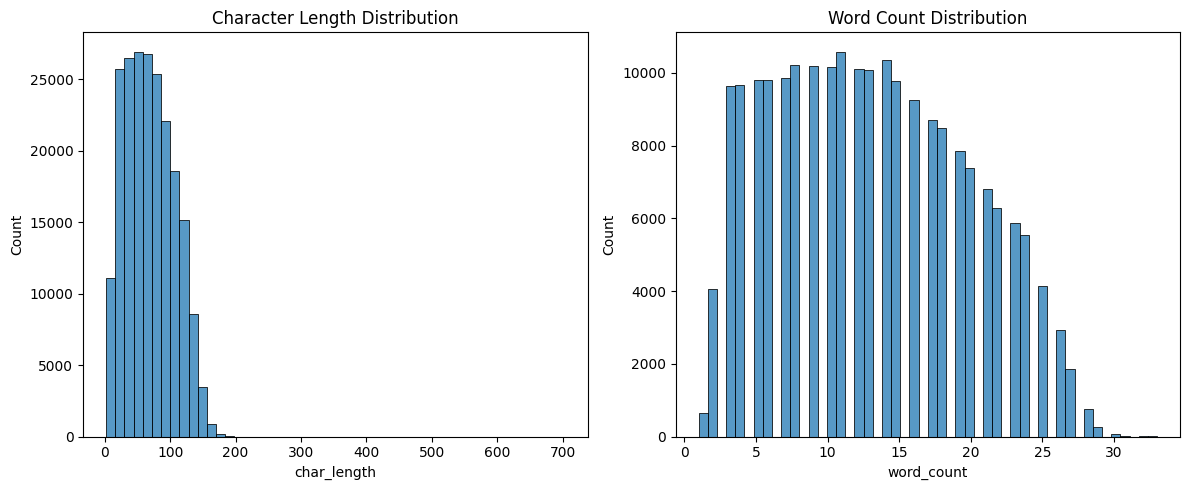

In [ ]:
df['char_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['char_length'], bins=50)
plt.title("Character Length Distribution")
plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()

## **Data Cleaning**

In [ ]:
df.columns

Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral', 'char_length',
       'word_count'],
      dtype='object')

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df[df['text'].notnull()]                        # drop rows with no text
df = df[df['text'].str.strip() != '']                # drop rows that are just spaces
df = df[df['example_very_unclear'] == False]         # drop rows marked unclear

print(f"Rows remaining: {len(df):,}")

Rows remaining: 207,814


In [ ]:
df = df[df['text'].str.len() >= 15]
df = df[df['text'].str.len() <= 300]

print(f"Rows remaining: {len(df):,}")

Rows remaining: 200,651


In [ ]:
POSITIVE_WORDS = {
    "happy","love","great","amazing","wonderful","fantastic","excellent",
    "good","joy","excited","thrilled","delighted","grateful","thankful",
    "blessed","proud","awesome","brilliant","cheerful","glad","pleased",
    "ecstatic","euphoric","elated","overjoyed","blissful","content",
}
NEGATIVE_WORDS = {
    "sad","angry","hate","terrible","awful","horrible","bad","worst",
    "depressed","miserable","devastated","heartbroken","furious","disgusted",
    "disappointed","hopeless","worthless","pathetic","dreadful","painful",
    "regret","sorry","guilty","ashamed","embarrassed","scared","anxious",
}
FEAR_WORDS = {
    "scared","afraid","terrified","anxious","nervous","worried","panic",
    "fear","dread","horror","frightened","uneasy","apprehensive","phobia",
}
ANGER_WORDS = {
    "angry","furious","rage","mad","outraged","livid","infuriated","hate",
    "disgusted","annoyed","frustrated","irritated","bitter","resentful",
}

In [ ]:
STOPWORDS = {
    "a","an","the","and","or","but","in","on","at","to","for","of",
    "with","by","from","is","are","was","were","be","been","have",
    "has","had","do","does","did","will","would","could","should",
    "may","might","i","me","my","we","our","you","your","he","she",
    "it","they","them","their","this","that","these","those","not",
    "no","so","if","as","up","out","just","then","than","into",
    "about","also","its","get","got","go","come","see","know",
    "think","want","need","use","like","make","take","give","find",
    "tell","feel","try","keep","let","someone",
}

def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'u/\w+|r/\w+', ' ', text)
    text = re.sub(r'\[deleted\]|\[removed\]', ' ', text)
    text = re.sub(r'[^a-z\s!?]', ' ', text)  # keep ! and ?
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\b\w\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_meaningful(text):
    if not text or not text.strip():
        return False
    tokens = text.split()
    if len(tokens) < 4:                                   # at least 4 words
        return False
    if len(set(tokens)) == 1:                             # "lol lol lol"
        return False
    content = [t for t in tokens if t not in STOPWORDS]
    if len(content) == 0:                                 # only stopwords
        return False
    vowel_words = sum(1 for w in tokens if re.search(r'[aeiou]', w))
    if vowel_words < 2:                                   # keyboard smashing
        return False
    return True

In [ ]:
df['text'] = df['text'].apply(clean_text)
df = df[df['text'].apply(is_meaningful)].reset_index(drop=True)
df = df[df['text'].str.split().str.len() >= 4].reset_index(drop=True)
print(f"After cleaning: {len(df):,} rows")

After cleaning: 191,390 rows


## **Grouping Emotions**

In [ ]:
GROUPS = {
    "joy_excitement":   ["joy","amusement","excitement","pride","optimism","relief","surprise"],
    "affection":        ["love","admiration","caring","gratitude","approval"],
    "anger_disgust":    ["anger","annoyance","disapproval","disgust"],
    "sadness_grief":    ["sadness","grief","disappointment","remorse","desire"],
    "fear_nervousness": ["fear","nervousness","embarrassment","confusion","curiosity","realization"],
}

In [ ]:
GROUP_NAMES = list(GROUPS.keys())

for group, fine_list in GROUPS.items():
    df[group] = df[fine_list].max(axis=1)

df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"After deduplication: {len(df):,} rows")

After deduplication: 53,037 rows


In [ ]:
PRIORITY = [
    "anger_disgust", "fear_nervousness", "sadness_grief",
    "affection", "joy_excitement"
]

def pick_one_emotion(row):
    active = [g for g in PRIORITY if row[g] == 1]
    if not active:
        return None
    return active[0]

df['emotion'] = df.apply(pick_one_emotion, axis=1)
df = df[df['emotion'].notnull()].reset_index(drop=True)

print(f"\nBefore capping: {len(df):,}")
print(df['emotion'].value_counts())

MAX_PER_CLASS = 4000
df = df.groupby('emotion', group_keys=False).apply(
    lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=42)
).reset_index(drop=True)

print(f"\nAfter capping: {len(df):,} rows")
print(df['emotion'].value_counts())


Before capping: 38,829
emotion
affection           12207
anger_disgust        8576
fear_nervousness     7594
joy_excitement       6281
sadness_grief        4171
Name: count, dtype: int64

After capping: 20,000 rows
emotion
affection           4000
anger_disgust       4000
fear_nervousness    4000
joy_excitement      4000
sadness_grief       4000
Name: count, dtype: int64


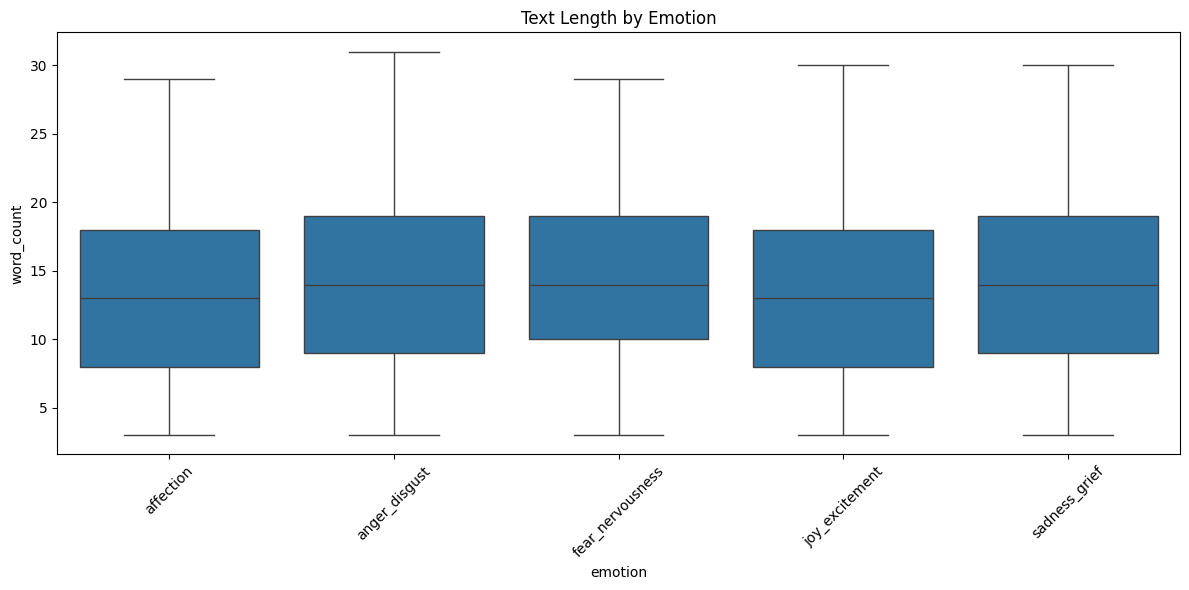

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='emotion', y='word_count', data=df)
plt.xticks(rotation=45)
plt.title("Text Length by Emotion")
plt.tight_layout()
plt.show()


## **Emotion Count**

In [ ]:
counts = df['emotion'].value_counts()
pct    = counts / len(df) * 100
print("Emotion counts:")
print(pd.DataFrame({'count': counts, 'percent': pct.round(1)}))


Emotion counts:
                  count  percent
emotion                         
affection          4000     20.0
anger_disgust      4000     20.0
fear_nervousness   4000     20.0
joy_excitement     4000     20.0
sadness_grief      4000     20.0


In [ ]:
df_final = df[['text', 'emotion']].reset_index(drop=True)
df_final.head()

,text,emotion
0,pretty jelly now lol esp the pear shape,affection
1,name and name as alternate costumes of each ot...,affection
2,yeah want all our players to have nice healthy...,affection
3,always!! especially love when they ask for the...,affection
4,even while name in america are discriminated a...,affection


## **Label Encoding Groups**

In [ ]:
le = LabelEncoder()
df_final['label'] = le.fit_transform(df_final['emotion'])

for num, name in enumerate(le.classes_):
    print(f"  {num}  →  {name}")

  0  →  affection
  1  →  anger_disgust
  2  →  fear_nervousness
  3  →  joy_excitement
  4  →  sadness_grief


# **Train-Test Split**

In [ ]:
X = df_final['text'].values
y = df_final['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
print(f"\nTraining: {len(X_train):,}  |  Test: {len(X_test):,}")


Training: 17,000  |  Test: 3,000


In [ ]:
df_final.head()

,text,emotion,label
0,pretty jelly now lol esp the pear shape,affection,0
1,name and name as alternate costumes of each ot...,affection,0
2,yeah want all our players to have nice healthy...,affection,0
3,always!! especially love when they ask for the...,affection,0
4,even while name in america are discriminated a...,affection,0


# **Model Development**

In [ ]:
from sentence_transformers import SentenceTransformer
# This converts each sentence into a list of numbers that captures meaning

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from xgboost               import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE

In [ ]:
embedder = SentenceTransformer("all-mpnet-base-v2")

X_train_emb = embedder.encode(
    X_train.tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True
)
X_test_emb = embedder.encode(
    X_test.tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True
)
print(f"\nEmbedding shape — Train: {X_train_emb.shape}  |  Test: {X_test_emb.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/266 [00:00<?, ?it/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]


Embedding shape — Train: (17000, 768)  |  Test: (3000, 768)


In [ ]:
def extract_features(text):
    original = str(text)                        # preserve for caps/punct
    lower    = original.lower()
    tokens   = lower.split()
    n        = max(len(tokens), 1)              # avoid div-by-zero

    # Punctuation & style
    exclamation_count  = original.count('!')
    question_count     = original.count('?')
    has_multiple_excl  = int(exclamation_count >= 2)
    has_excl_question  = int('!?' in original or '?!' in original)
    caps_ratio         = sum(1 for c in original if c.isupper()) / max(len(original), 1)
    is_all_caps        = int(original.isupper())

    # Length
    word_count         = len(tokens)
    char_count         = len(original)
    avg_word_length    = np.mean([len(w) for w in tokens]) if tokens else 0
    unique_word_ratio  = len(set(tokens)) / n

    # Repetition
    has_repeated_chars = int(bool(re.search(r'(.)\1{2,}', lower)))
    has_repeated_words = int(any(tokens[i] == tokens[i-1] for i in range(1, len(tokens))))

    # Negation
    negation_words = {"not","no","never","nothing","nobody","neither",
                      "nor","none","cant","cannot","dont","wont","shouldnt"}
    negation_count = sum(1 for t in tokens if t in negation_words)

    # Emotion lexicon counts
    pos_count   = sum(1 for t in tokens if t in POSITIVE_WORDS)
    neg_count   = sum(1 for t in tokens if t in NEGATIVE_WORDS)
    fear_count  = sum(1 for t in tokens if t in FEAR_WORDS)
    anger_count = sum(1 for t in tokens if t in ANGER_WORDS)

    # Normalised ratios
    pos_ratio   = pos_count  / n
    neg_ratio   = neg_count  / n
    fear_ratio  = fear_count / n
    anger_ratio = anger_count / n

    # Net sentiment
    sentiment_score = (pos_count - neg_count) / n

    # First-person usage
    first_person = {"i","me","my","myself","im","ive","id","ill"}
    first_person_ratio = sum(1 for t in tokens if t in first_person) / n

    return [
        exclamation_count, question_count,
        has_multiple_excl, has_excl_question,
        caps_ratio, is_all_caps,
        word_count, char_count, avg_word_length, unique_word_ratio,
        has_repeated_chars, has_repeated_words,
        negation_count,
        pos_count, neg_count, fear_count, anger_count,
        pos_ratio, neg_ratio, fear_ratio, anger_ratio,
        sentiment_score,
        first_person_ratio,
    ]

FEATURE_NAMES = [
    "exclamation_count","question_count","has_multiple_excl","has_excl_question",
    "caps_ratio","is_all_caps",
    "word_count","char_count","avg_word_length","unique_word_ratio",
    "has_repeated_chars","has_repeated_words",
    "negation_count",
    "pos_count","neg_count","fear_count","anger_count",
    "pos_ratio","neg_ratio","fear_ratio","anger_ratio",
    "sentiment_score",
    "first_person_ratio",
]

print("\nExtracting hand-crafted features...")
train_feats_raw = np.array([extract_features(t) for t in X_train])
test_feats_raw  = np.array([extract_features(t) for t in X_test])


Extracting hand-crafted features...


In [ ]:
scaler = StandardScaler()
train_feats = scaler.fit_transform(train_feats_raw)
test_feats  = scaler.transform(test_feats_raw)

print(f"Hand-crafted features — Train: {train_feats.shape}  |  Test: {test_feats.shape}")

# Combine: 768 embedding dims + 23 hand-crafted = 791 total
X_train_combined = np.hstack([X_train_emb, train_feats])
X_test_combined  = np.hstack([X_test_emb,  test_feats])

print(f"Combined shape — Train: {X_train_combined.shape}  |  Test: {X_test_combined.shape}")
print(f"  {X_train_emb.shape[1]} embedding dims  +  {train_feats.shape[1]} hand-crafted  =  {X_train_combined.shape[1]} total")

Hand-crafted features — Train: (17000, 23)  |  Test: (3000, 23)
Combined shape — Train: (17000, 791)  |  Test: (3000, 791)
  768 embedding dims  +  23 hand-crafted  =  791 total


# **Model Training**

## **Logistic Regression**

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=10,
    solver='lbfgs',
    class_weight='balanced',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_combined, y_train)
lr_preds = lr_model.predict(X_test_combined)
print(f"\nLogistic Regression  —  Accuracy: {accuracy_score(y_test, lr_preds):.4f}  "
      f"F1: {f1_score(y_test, lr_preds, average='macro'):.4f}")


Logistic Regression  —  Accuracy: 0.5027  F1: 0.5026


## **Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42,
    n_jobs=-1, class_weight='balanced'
)
rf_model.fit(X_train_combined, y_train)
rf_preds = rf_model.predict(X_test_combined)
print(f"Random Forest        —  Accuracy: {accuracy_score(y_test, rf_preds):.4f}  "
      f"F1: {f1_score(y_test, rf_preds, average='macro'):.4f}")


Random Forest        —  Accuracy: 0.4270  F1: 0.4260


## **XGB**


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    eval_metric="mlogloss", random_state=42, n_jobs=-1, tree_method="hist"
)
xgb_model.fit(X_train_combined, y_train)
xgb_preds = xgb_model.predict(X_test_combined)
print(f"XGBoost              —  Accuracy: {accuracy_score(y_test, xgb_preds):.4f}  "
      f"F1: {f1_score(y_test, xgb_preds, average='macro'):.4f}")

XGBoost              —  Accuracy: 0.4753  F1: 0.4761


## **Cross Validation- kfold**

In [ ]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds = faster

acc_scores = cross_val_score(lr_model, X_train_combined, y_train,
                              cv=skf, scoring="accuracy", n_jobs=-1)
f1_scores  = cross_val_score(lr_model, X_train_combined, y_train,
                              cv=skf, scoring="f1_macro",  n_jobs=-1)

print(f"\nCross Validation (Logistic Regression):")
print(f"  Accuracy per fold : {[round(s,4) for s in acc_scores]}")
print(f"  F1 per fold       : {[round(s,4) for s in f1_scores]}")
print(f"  Mean Accuracy     : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"  Mean F1 Score     : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print("Small ± = stable model, not dependent on one lucky split.")


Cross Validation (Logistic Regression):
  Accuracy per fold : [np.float64(0.465), np.float64(0.4673), np.float64(0.4884)]
  F1 per fold       : [np.float64(0.4647), np.float64(0.4672), np.float64(0.4886)]
  Mean Accuracy     : 0.4735 ± 0.0105
  Mean F1 Score     : 0.4735 ± 0.0107
Small ± = stable model, not dependent on one lucky split.


Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [1, 5, 10, 20, 50]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='lbfgs',
                       class_weight='balanced',
                       multi_class='multinomial', random_state=42),
    param_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1
)
grid.fit(X_train_combined, y_train)

print(f"Best C     : {grid.best_params_['C']}")
print(f"Best CV F1 : {grid.best_score_:.4f}")

tuned_lr    = grid.best_estimator_
tuned_preds = tuned_lr.predict(X_test_combined)

print(f"Tuned LR — Accuracy: {accuracy_score(y_test, tuned_preds):.4f}  "
      f"F1: {f1_score(y_test, tuned_preds, average='macro'):.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best C     : 1
Best CV F1 : 0.4928
Tuned LR — Accuracy: 0.5037  F1: 0.5036


Feature Importance


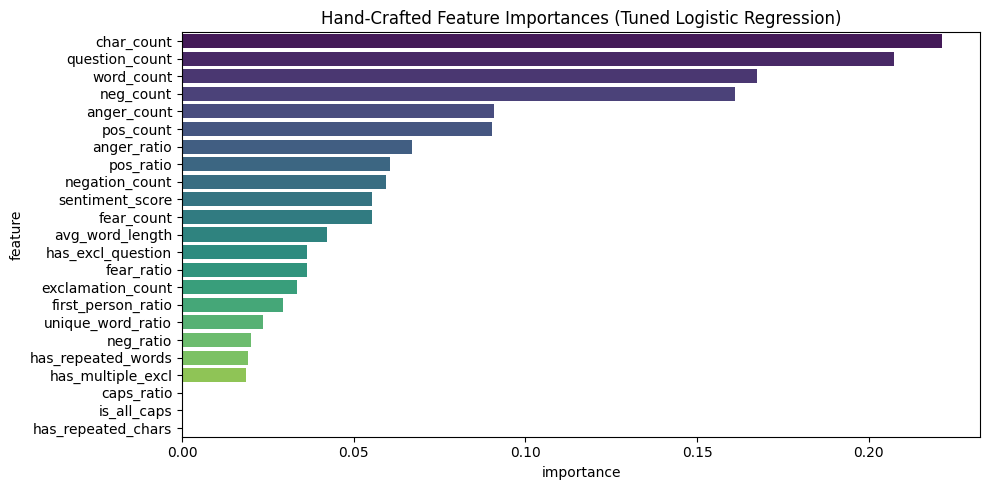


Top 10 most important hand-crafted features:
        feature  importance
     char_count    0.221275
 question_count    0.207175
     word_count    0.167357
      neg_count    0.161146
    anger_count    0.090738
      pos_count    0.090330
    anger_ratio    0.067085
      pos_ratio    0.060529
 negation_count    0.059376
sentiment_score    0.055375


In [ ]:
feat_start = X_train_emb.shape[1]   # 768 — where hand-crafted features begin

# Get coefficients for hand-crafted features only (shape: n_classes × n_features)
lr_coefs = np.abs(tuned_lr.coef_[:, feat_start:])

# Average absolute coefficient across all 5 classes
mean_importance = lr_coefs.mean(axis=0)

feat_imp_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feat_imp_df, palette='viridis')
plt.title("Hand-Crafted Feature Importances (Tuned Logistic Regression)")
plt.tight_layout(); plt.show()

print("\nTop 10 most important hand-crafted features:")
print(feat_imp_df.head(10).to_string(index=False))

## **Comapring All Models**

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Tuned LR"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
        accuracy_score(y_test, tuned_preds),
    ],
    "F1 Score (macro)": [
        f1_score(y_test, lr_preds,    average='macro'),
        f1_score(y_test, rf_preds,    average='macro'),
        f1_score(y_test, xgb_preds,   average='macro'),
        f1_score(y_test, tuned_preds, average='macro'),
    ]
})
results["Accuracy"]         = results["Accuracy"].round(4)
results["F1 Score (macro)"] = results["F1 Score (macro)"].round(4)
print("\n", results.to_string(index=False))


               Model  Accuracy  F1 Score (macro)
Logistic Regression    0.5027            0.5026
      Random Forest    0.4270            0.4260
            XGBoost    0.4753            0.4761
           Tuned LR    0.5037            0.5036


## **Visualization**

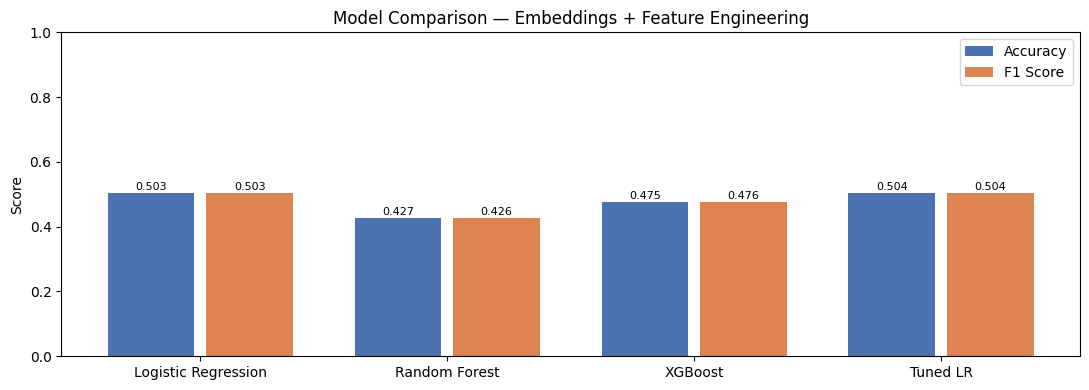

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results))
bars1 = ax.bar(x - 0.2, results["Accuracy"],         0.35, label="Accuracy", color="#4C72B0")
bars2 = ax.bar(x + 0.2, results["F1 Score (macro)"], 0.35, label="F1 Score", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(results["Model"])
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("Model Comparison — Embeddings + Feature Engineering")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
model_scores = {
    "lr":       f1_score(y_test, lr_preds,    average='macro'),
    "rf":       f1_score(y_test, rf_preds,    average='macro'),
    "xgb":      f1_score(y_test, xgb_preds,   average='macro'),
    "tuned_lr": f1_score(y_test, tuned_preds, average='macro'),
}
best_model_name = max(model_scores, key=model_scores.get)
pred_map      = {"lr": lr_preds, "rf": rf_preds,
                 "xgb": xgb_preds, "tuned_lr": tuned_preds}
model_obj_map = {"lr": lr_model, "rf": rf_model,
                 "xgb": xgb_model, "tuned_lr": tuned_lr}
best_preds     = pred_map[best_model_name]
best_model_obj = model_obj_map[best_model_name]

print(f"\nBest model: {best_model_name}  —  F1: {model_scores[best_model_name]:.4f}")
print(classification_report(y_test, best_preds, target_names=le.classes_))


Best model: tuned_lr  —  F1: 0.5036
                  precision    recall  f1-score   support

       affection       0.53      0.51      0.52       600
   anger_disgust       0.47      0.55      0.51       600
fear_nervousness       0.52      0.48      0.50       600
  joy_excitement       0.49      0.48      0.48       600
   sadness_grief       0.51      0.50      0.51       600

        accuracy                           0.50      3000
       macro avg       0.51      0.50      0.50      3000
    weighted avg       0.51      0.50      0.50      3000



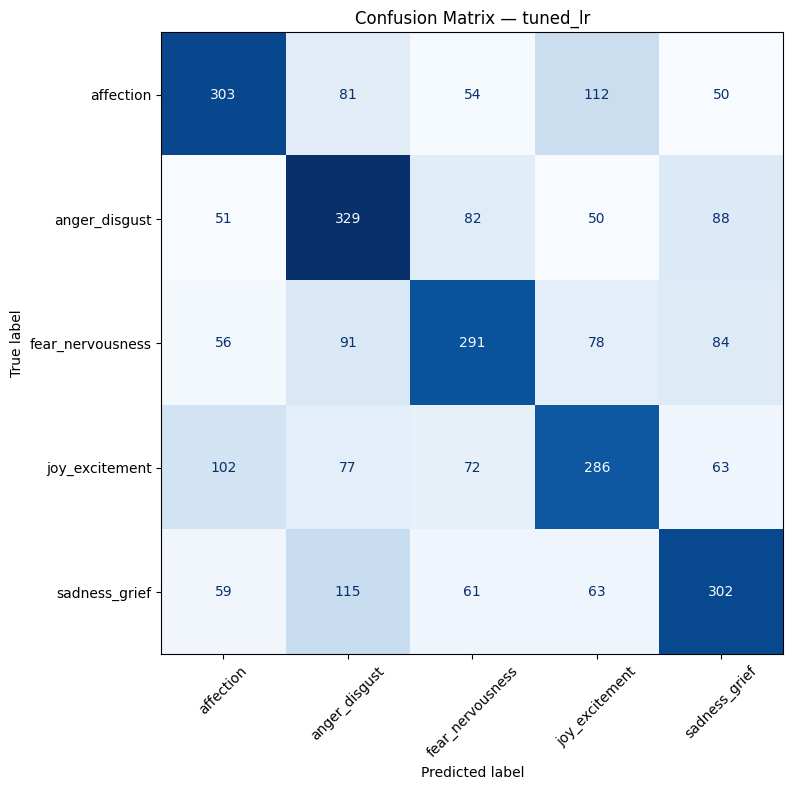

In [ ]:
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout(); plt.show()

# **Testing**

In [ ]:
def predict_emotion(text):
    # Use original text for feature extraction (caps/punct matter)
    feats_raw = np.array([extract_features(text)])
    feats     = scaler.transform(feats_raw)

    # Clean for embedding
    cleaned = str(text).lower()
    cleaned = re.sub(r'https?://\S+', ' ', cleaned)
    cleaned = re.sub(r'[^a-z\s!?]',  ' ', cleaned)
    cleaned = re.sub(r'\s+',          ' ', cleaned).strip()
    emb = embedder.encode([cleaned], convert_to_numpy=True)

    vec  = np.hstack([emb, feats])
    pred = best_model_obj.predict(vec)[0]
    return le.inverse_transform([pred])[0]

print("Testing:")
sentences = [
    "I just got promoted, I can't believe it!",
    "Everything feels so pointless lately.",
    "Why would anyone do something like that??",
    "I feel so scared and nervous about tomorrow.",
    "I love how caring and kind you are.",
    "I AM SO DONE WITH THIS!!!",
    "Not sure what to think, this is all so confusing.",
]
for s in sentences:
    print(f"  '{s}'")
    print(f"   → {predict_emotion(s)}\n")


Testing:
  'I just got promoted, I can't believe it!'
   → joy_excitement

  'Everything feels so pointless lately.'
   → sadness_grief

  'Why would anyone do something like that??'
   → fear_nervousness

  'I feel so scared and nervous about tomorrow.'
   → fear_nervousness

  'I love how caring and kind you are.'
   → affection

  'I AM SO DONE WITH THIS!!!'
   → joy_excitement

  'Not sure what to think, this is all so confusing.'
   → fear_nervousness



In [ ]:
joblib.dump(best_model_obj, "best_model.joblib")
joblib.dump(le,             "label_encoder.joblib")
joblib.dump(scaler,         "feature_scaler.joblib")
with open("embedder_name.txt", "w") as f:
    f.write("all-mpnet-base-v2")

print("Saved: best_model.joblib, label_encoder.joblib, feature_scaler.joblib, embedder_name.txt")

Saved: best_model.joblib, label_encoder.joblib, feature_scaler.joblib, embedder_name.txt


In [ ]:
import joblib

# Save model and preprocessors as .pkl files
joblib.dump(best_model_obj, "best_model.pkl")
joblib.dump(le,             "label_encoder.pkl")
joblib.dump(scaler,         "feature_scaler.pkl")

# Save embedder name
with open("embedder_name.txt", "w") as f:
    f.write("all-mpnet-base-v2")

print("Saved: best_model.pkl, label_encoder.pkl, feature_scaler.pkl, embedder_name.txt")

Saved: best_model.pkl, label_encoder.pkl, feature_scaler.pkl, embedder_name.txt
